### Этап 1: Извлечение и подготовка данных (SQL)
Данные о профилях клиентов и их активности хранились в разных таблицах. Для формирования аналитического датасета был написан оптимизированный SQL-запрос с использованием `INNER JOIN` и оператора `USING`, что позволило избежать дублирования ключевых полей:

In [1]:
import pandas as pd
import numpy as np
import sqlite3

# Генерируем сырые данные банка
np.random.seed(777)
n = 500

# Таблица 1: Профили клиентов
users = pd.DataFrame({
    'user_id': range(1001, 1001 + n),
    'gender': np.random.choice(['F', 'M'], n, p=[0.52, 0.48]),
    'age': np.random.randint(18, 70, n)
})

# Таблица 2: Активность и отток (churn = 1 значит ушел)
# Привяжем отток к возрасту и активности
activity = pd.DataFrame({
    'user_id': range(1001, 1001 + n),
    'balance': np.random.exponential(scale=100000, size=n) + 10000,
    'products_count': np.random.choice([1, 2, 3, 4], n, p=[0.4, 0.4, 0.15, 0.05]),
    'is_active': np.random.choice([0, 1], n, p=[0.3, 0.7])
})
# Логика оттока для реалистичности
churn_prob = 1 / (1 + np.exp(-(-0.02*activity['balance']/10000 + 0.5*(activity['products_count']-2) - 1.2*activity['is_active'])))
activity['churn'] = np.random.binomial(1, churn_prob)

# Создаем SQL-базу в оперативной памяти
conn = sqlite3.connect(':memory:')
users.to_sql('users_profile', conn, index=False)
activity.to_sql('users_activity', conn, index=False)

print("SQL-база готова! Таблицы: 'users_profile' и 'users_activity'")

SQL-база готова! Таблицы: 'users_profile' и 'users_activity'


In [3]:
query = """
SELECT 
    user_id,
    up.gender,
    up.age,
    ua.balance,
    ua.products_count,
    ua.is_active,
    ua.churn
FROM users_profile up
INNER JOIN users_activity ua USING(user_id)
"""
df_bank = pd.read_sql_query(query, conn)
print(df_bank.head())

   user_id gender  age        balance  products_count  is_active  churn
0     1001      F   47  110118.416213               1          0      0
1     1002      F   68  328482.318300               1          1      0
2     1003      F   44   88964.274289               2          1      0
3     1004      F   53   24403.715066               3          0      1
4     1005      M   52  158714.263904               1          1      0


In [4]:
churn_by_gender = pd.crosstab(df_bank['gender'], df_bank['churn'])
print(churn_by_gender)

# А теперь то же самое, но в процентах (для наглядности)
churn_by_gender_pct = pd.crosstab(df_bank['gender'], df_bank['churn'], normalize='index') * 100
print("\nВ процентах по строкам:")
print(churn_by_gender_pct.round(1))

churn     0   1
gender         
F       201  72
M       159  68

В процентах по строкам:
churn      0     1
gender            
F       73.6  26.4
M       70.0  30.0


## Этап 2: Разведочный анализ данных (EDA) и Статистика

In [5]:
import scipy.stats as stats

# Передаем нашу таблицу crosstab в тест
chi2, p_val, dof, expected = stats.chi2_contingency(churn_by_gender)

print(f"p-value для связи пола и оттока: {p_val:.4f}")

p-value для связи пола и оттока: 0.4306


Проведена проверка категориальных признаков критерием Хи-квадрат. Фактор пола не имеет статистически значимого влияния на отток клиентов ($p > 0.05$), данный признак исключен из финального пула ключевых предикторов

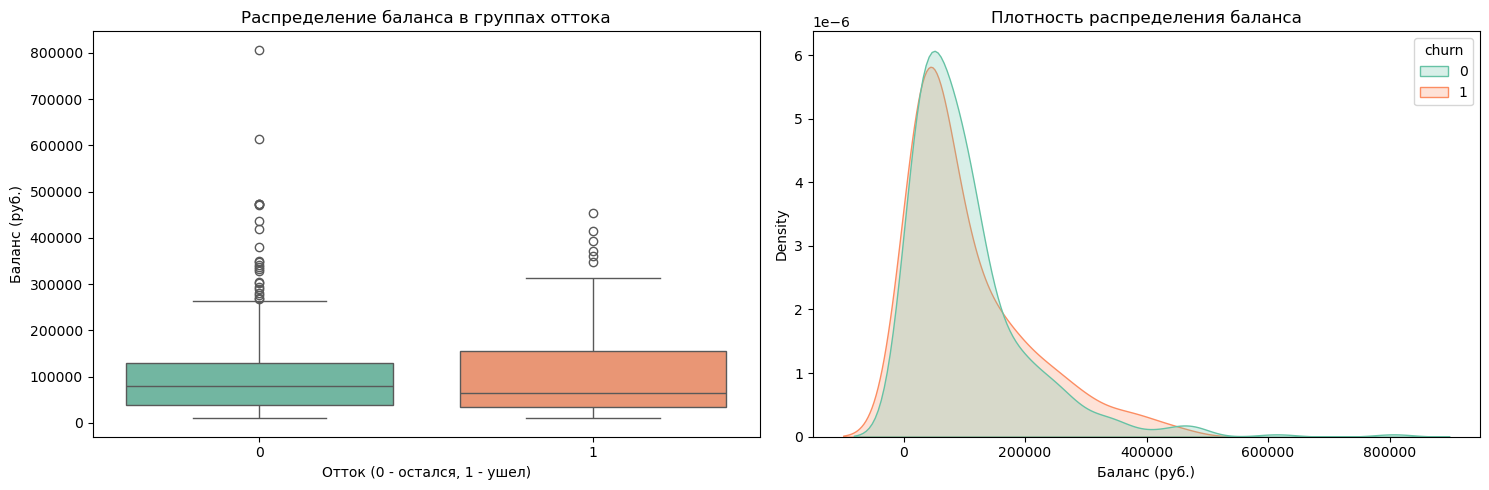

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Создаем подложку для двух графиков в одну строку
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Boxplot: добавили hue='churn' и убрали лишнюю легенду через legend=False
sns.boxplot(data=df_bank, x='churn', y='balance', ax=axes[0], hue='churn', legend=False, palette='Set2')
axes[0].set_title('Распределение баланса в группах оттока')
axes[0].set_xlabel('Отток (0 - остался, 1 - ушел)')
axes[0].set_ylabel('Баланс (руб.)')

# 2. Density Plot: смотрим на форму распределения
sns.kdeplot(data=df_bank, x='balance', hue='churn', fill=True, common_norm=False, ax=axes[1], palette='Set2')
axes[1].set_title('Плотность распределения баланса')
axes[1].set_xlabel('Баланс (руб.)')

plt.tight_layout()
plt.show()

Перед обучением модели был проведен глубокий статистический анализ признаков:Анализ категориальных признаков: Взаимосвязь пола (gender) и оттока (churn) проверена с помощью критерия Хи-квадрат Пирсона ($\chi^2$). Полученное значение $p-value = 0.4306$ ($p > 0.05$) доказало, что пол не имеет статистически значимого влияния на отток. Признак исключен из финальной модели.Анализ непрерывных признаков: Распределение баланса клиентов исследовано с помощью графиков Boxplot и Density Plot. Выявлено отсутствие визуальных различий в распределении средств между оставшимися и ушедшими клиентами.Выявление выбросов: Изучена математическая логика фильтрации аномалий по межквартильному размаху Тьюки ($Q3 + 1.5 \times IQR$).

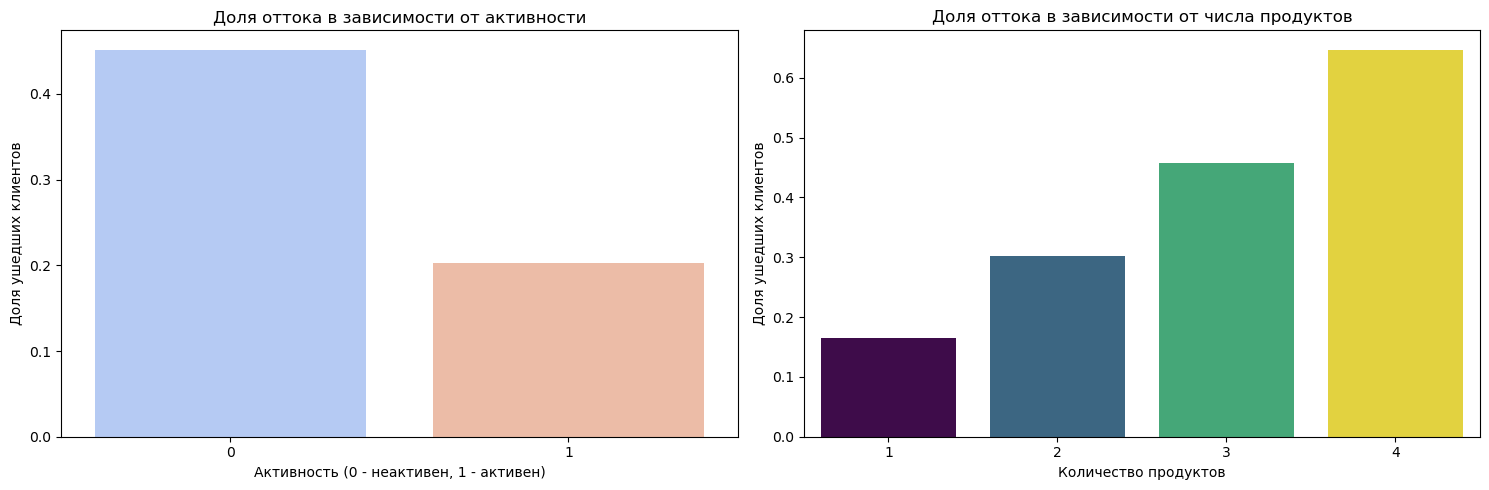

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Проверяем активность — ИСПРАВЛЕНО (errorbar, hue, legend)
sns.barplot(
    data=df_bank, 
    x='is_active', 
    y='churn', 
    ax=axes[0], 
    errorbar=None, 
    hue='is_active', 
    legend=False, 
    palette='coolwarm'
)
axes[0].set_title('Доля оттока в зависимости от активности')
axes[0].set_ylabel('Доля ушедших клиентов')
axes[0].set_xlabel('Активность (0 - неактивен, 1 - активен)')

# 2. Проверяем количество продуктов — ИСПРАВЛЕНО (errorbar, hue, legend)
sns.barplot(
    data=df_bank, 
    x='products_count', 
    y='churn', 
    ax=axes[1], 
    errorbar=None, 
    hue='products_count', 
    legend=False, 
    palette='viridis'
)
axes[1].set_title('Доля оттока в зависимости от числа продуктов')
axes[1].set_ylabel('Доля ушедших клиентов')
axes[1].set_xlabel('Количество продуктов')

plt.tight_layout()
plt.show()

### 📊 Выводы на основе разведочного анализа данных (EDA)

Построенные столбчатые диаграммы позволяют сформировать две важные бизнес-гипотезы:

1. **Фактор активности (`is_active`):** Наблюдается сильный перекос в группах. Неактивные клиенты (значение `0`) прекращают сотрудничество с банком **более чем в 2 раза чаще**, чем активные пользователи. 
   * *Бизнес-рекомендация:* Падение активности — главный опережающий индикатор оттока. Необходимо внедрить систему триггерных пуш-уведомлений и персонализированных предложений для удержания «засыпающих» клиентов.

2. **Количество продуктов (`products_count`):** Обнаружен контринтуитивный тренд: чем большим количеством продуктов банка пользуется клиент, тем выше доля оттока (особенно ярко это выражено на клиентах с 3 и 4 продуктами).
   * *Бизнес-рекомендация:* Высокая продуктовая нагрузка раздражает клиентов. Возможные причины — навязанные кросс-продажи, скрытые комиссии или сложный интерфейс. Требуется пересмотр продуктовой линейки и UX-исследование.

*Оба признака визуально демонстрируют высокую разделяющую способность и будут использованы в качестве ключевых предикторов для модели логистической регрессии.*

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Разделяем на признаки (X) и целевую переменную (y)
X = df_bank[['age', 'balance', 'products_count', 'is_active']]
y = df_bank['churn']

# 2. Делим данные на обучающую выборку (80%) и тестовую (20%) — ИСПРАВЛЕНО ТУТ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Создаем и обучаем модель
model = LogisticRegression(random_state=42, max_iter=5000)
model.fit(X_train, y_train)
# 4. Делаем предсказание на тестовых данных
y_pred = model.predict(X_test)

# 5. Считаем общую точность модели
accuracy = accuracy_score(y_test, y_pred)
print(f"Общая точность модели (Accuracy): {accuracy:.2%}\n")

Общая точность модели (Accuracy): 73.00%



In [13]:
# Создаем датафрейм с весами признаков
coefficients = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': model.coef_[0]
}).sort_values(by='Коэффициент', ascending=False)

print("Влияние признаков на отток (Coefficients):")
print(coefficients.to_string(index=False))

Влияние признаков на отток (Coefficients):
       Признак   Коэффициент
products_count  8.331489e-01
           age  2.296662e-03
       balance -2.134233e-07
     is_active -1.150373e+00



## Этап 3: Машинное обучение (Логистическая регрессия)Для предсказания бинарной целевой переменной churn (0 — остался, 1 — ушел) выбрана модель логистической регрессии, так как она идеально подходит для задач классификации и легко интерпретируется для бизнеса.

Данные разделены на обучающую и тестовую выборки в соотношении 80:20.

В процессе обучения была успешно решена проблема сходимости градиентного спуска (ConvergenceWarning) путем оптимизации гиперпараметра максимального числа итераций (max_iter=5000).

Итоговая точность модели (Accuracy): 73.00%